In [1]:
max_long = "4"
max_short = "1"
period = "21d"
stop_long = "0.5"
stop_short = "0.05"

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6895/6895 [00:16<00:00, 424.08it/s]


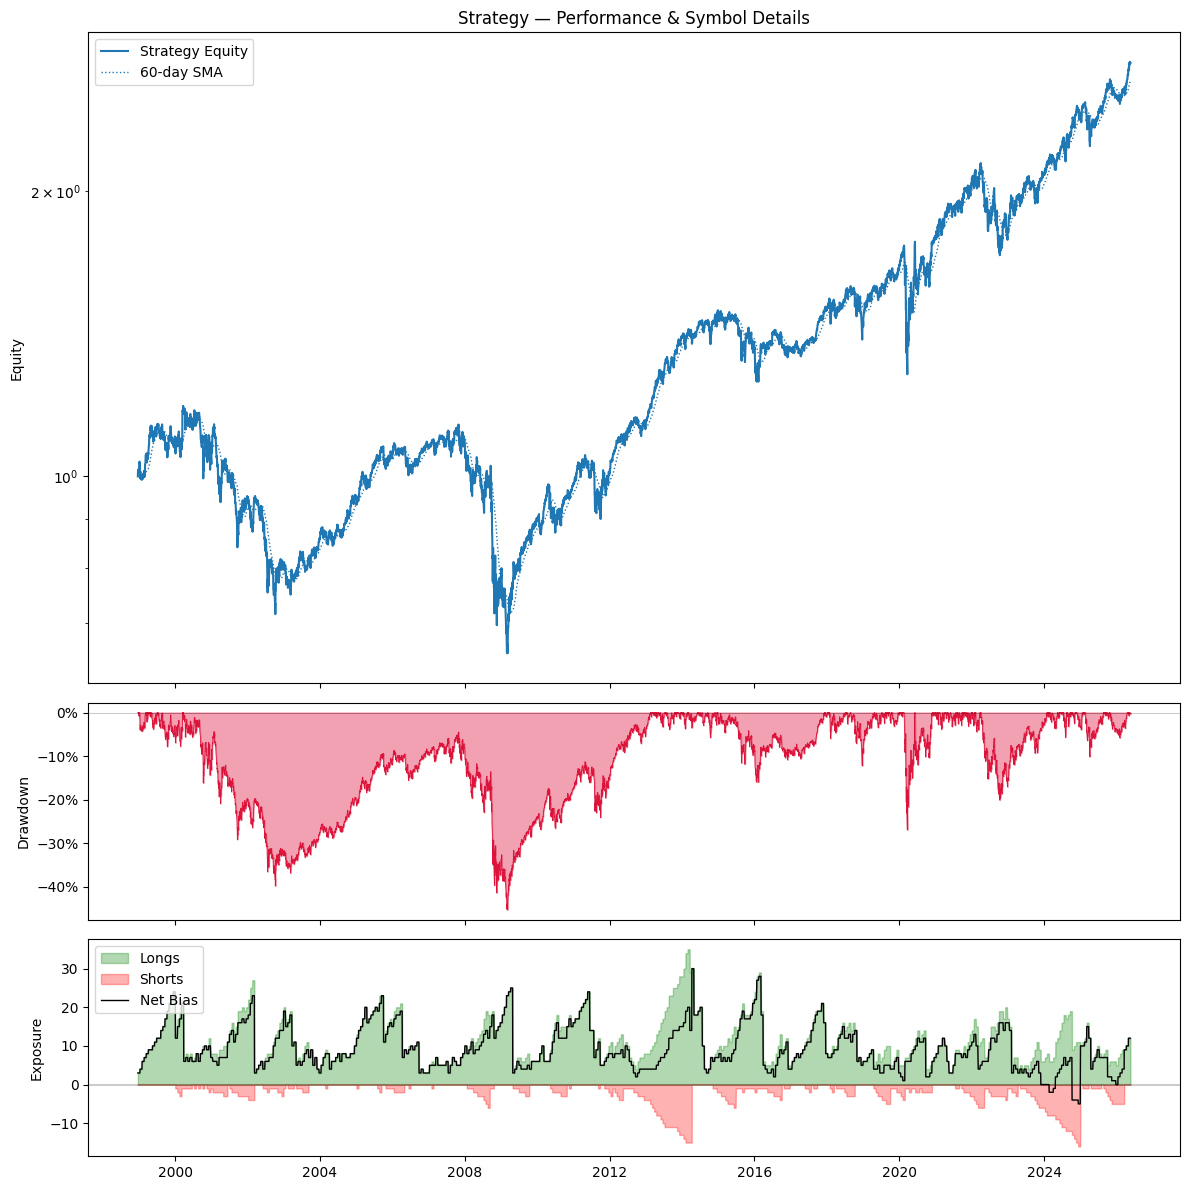

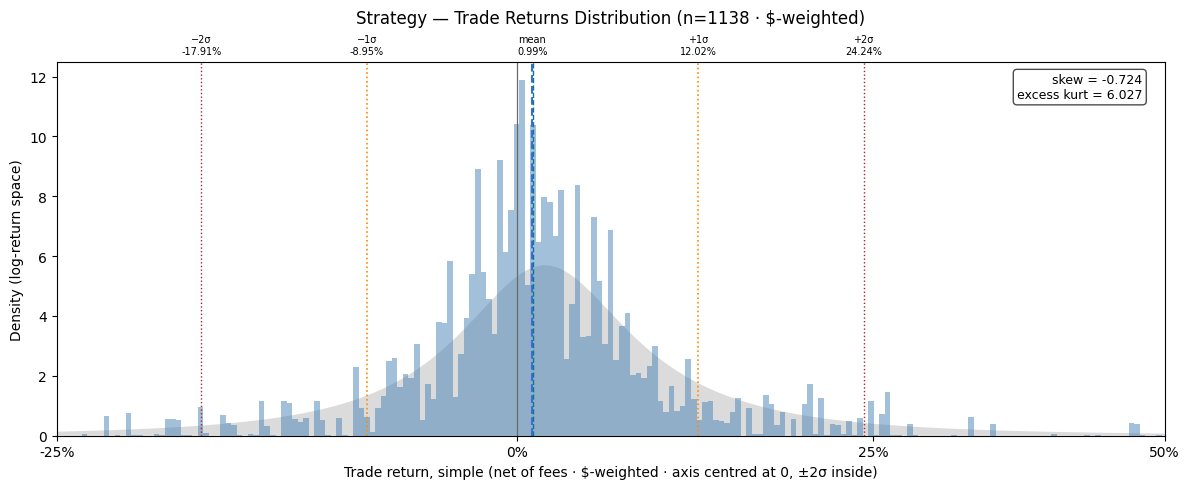

GT(_tbl_data=shape: (2, 14)
┌───────────┬──────────┬──────────┬──────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ Statistic ┆ CAGR     ┆ Sharpe   ┆ Sortino  ┆ … ┆ mae_mean  ┆ mae_stdev ┆ mfe_mean ┆ mfe_stdev │
│ ---       ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str       ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═══════════╪══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ Strategy  ┆ 0.054158 ┆ 0.411636 ┆ 0.526599 ┆ … ┆ -0.068958 ┆ 0.094752  ┆ 0.087803 ┆ 0.113028  │
│ Benchmark ┆ null     ┆ null     ┆ null     ┆ … ┆ null      ┆ null      ┆ null     ┆ null      │
└───────────┴──────────┴──────────┴──────────┴───┴───────────┴───────────┴──────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x300fa0310>, _boxhead=Boxhead([ColInfo(var='Statistic', type=<ColInfoTypeEnum.stub: 2>, column_label='Statistic', column_align='left', column_width=None), ColInfo(var='CAGR', type=<ColInfoTypeEnum.default: 1>, column_label='CAGR', column_align='right', column_width=None), ColInfo(var='Max DD', type=<ColInfoTypeEnum.default: 1>, column_label='Max DD', column_align='right', column_width=None), ColInfo(var='Fees', type=<ColInfoTypeEnum.default: 1>, column_label='Fees', column_align='right', column_width=None), ColInfo(var='Sharpe', type=<ColInfoTypeEnum.default: 1>, column_label='Sharpe', column_align='right', column_width=None), ColInfo(var='Sortino', type=<ColInfoTypeEnum.default: 1>, column_label='Sortino', column_align='right', column_width=None), ColInfo(var='IR', type=<ColInfoTypeEnum.default: 1>, column_label='IR', column_align='right', column_width=None), ColInfo(var='Half Kelly', type=<ColInfoTypeEnum.default: 1>, column_label='Half Kelly', column_align='right', column_width=None), ColInfo(var='return_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='return_stdev', type=<ColInfoTypeEnum.default: 1>, column_label='St. dev.', column_align='right', column_width=None), ColInfo(var='mae_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='mae_stdev', type=<ColInfoTypeEnum.default: 1>, column_label='St. dev.', column_align='right', column_width=None), ColInfo(var='mfe_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='mfe_stdev', type=<ColInfoTypeEnum.default: 1>, column_label='St. dev.', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x300eeccd0>, _spanners=Spanners([SpannerInfo(spanner_id='Performance', spanner_level=0, spanner_label='Performance', spanner_units=None, spanner_pattern=None, vars=['CAGR', 'Max DD', 'Fees'], built=None), SpannerInfo(spanner_id='Risk', spanner_level=0, spanner_label='Risk', spanner_units=None, spanner_pattern=None, vars=['Sharpe', 'Sortino', 'IR', 'Half Kelly'], built=None), SpannerInfo(spanner_id='Return', spanner_level=0, spanner_label='Return', spanner_units=None, spanner_pattern=None, vars=['return_mean', 'return_stdev'], built=None), SpannerInfo(spanner_id='Adverse', spanner_level=0, spanner_label='Adverse', spanner_units=None, spanner_pattern=None, vars=['mae_mean', 'mae_stdev'], built=None), SpannerInfo(spanner_id='Favorable', spanner_level=0, spanner_label='Favorable', spanner_units=None, spanner_pattern=None, vars=['mfe_mean', 'mfe_stdev'], built=None)]), _heading=Heading(title='Strategy', subtitle='Strategy Statistics', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x300fa0bb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x300fa0a90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='CAGR', rownum=0, colnum=None, styles=[CellStyleFill(color='#FFFFFF')]), StyleInfo(

Statistic,CAGR,Sharpe,Sortino,IR,Half Kelly,Max DD,Fees,return_mean,return_stdev,mae_mean,mae_stdev,mfe_mean,mfe_stdev
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Strategy""",0.054158,0.411636,0.526599,NaN,1.277966,-0.452105,7.562823,0.025422,0.133306,-0.068958,0.094752,0.087803,0.113028
"""Benchmark""",null,null,null,null,null,null,null,null,null,null,null,null,null


In [13]:
import backtest_ng as bt
import polars as pl

from typing import Dict


sector_etfs = [
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY",
]
start_year = 2020

class Alpha(bt.AlphaModel):
    def __init__(self, momentum_expr: pl.Expr, long_gate_expr: pl.Expr, short_gate_expr: pl.Expr,
                 indicators: Dict[str, pl.Expr]):
        self.momentum_expr = momentum_expr
        self.long_gate_expr = long_gate_expr
        self.short_gate_expr = short_gate_expr
        self.indicators = indicators
        self.max_long = 4
        self.max_short = 1
         

    def __call__(self, history: pl.DataFrame, u: bt.Universe) -> list[bt.Signal]:
        tscol = u.timestamp_col()
        symcol = u.symbol_col()
        df = (
            u.df()
            .with_columns(**self.indicators)
            .with_columns(
                score=self.momentum_expr.over(symcol)
            )
            .with_columns(
                lrank=pl.when(self.long_gate_expr)
                    .then((pl.col("score").rank(descending=True) / pl.len()).over(tscol))
                    .otherwise(None),
                srank=pl.when(self.short_gate_expr)
                    .then((pl.col("score").rank(descending=False) / pl.len()).over(tscol))
                    .otherwise(None),
            )
        )
        
        today = df[tscol].max()
        assert today is not None
        dfnow = df.filter(pl.col(tscol) == today)
        l = dfnow.sort("lrank")
        s = dfnow.sort("srank")
        
        ls = [
            bt.Signal(r[symcol], True, 1.0)
            for r in l.iter_rows(named=True)
        ]
        ss = [
            bt.Signal(r[symcol], False, -1.0)
            for r in s.iter_rows(named=True)
        ]

        return ls[:self.max_long] + ss[:self.max_short]

test = bt.Backtest(
    universe=bt.YFinance(
        tickers=sector_etfs,
        start=start_year,
    ),
    alpha=Alpha(
        momentum_expr=pl.col("mom12m") - pl.col("mom1m"),
        long_gate_expr=(pl.col("mom12m") > 0) | (pl.col("mom6m") > 0),
        short_gate_expr=(pl.col("mom12m") < 0) & (pl.col("mom6m") < 0),
        indicators={
            "mom1m": pl.col("close").pct_change(21).over("symbol"),
            "mom6m": pl.col("close").pct_change(21*6).over("symbol"),
            "mom12m": pl.col("close").pct_change(21*12).over("symbol"),
        }   
    ),
    #portfolio=bt.VolatilityWeighted(),
    #risk=bt.Fixed(
    #    long_trailing_pct=stop_long_P,
    #    short_trailing_pct=stop_short_P,
    #),
    #execution=bt.Schwab(
    #    base_rate_pct=10,
    #    maintainance_pct=30,
    #),
    benchmark='SPY',
    period=21,
)

test.run()
test.report(plot=True)

In [7]:
test.live(equity=10_000)

/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_91213/2736938796.py:54: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  dfnow = df.filter(pl.col(tscol) == today)


symbol,shares,position_value,entry_ts,exit_ts,entry_price
str,f64,f64,datetime[μs],datetime[μs],f64
